# Student Placement Prediction — Preprocessing and Modeling

This notebook prepares the student placement dataset for machine learning,
trains classification models, evaluates their performance, and compares the models.

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

## 1. Load Dataset

In [6]:
df = pd.read_csv(
    "..\\data\\raw\\student_placement_prediction_dataset_2026.csv"
)

df.head()

,student_id,age,gender,cgpa,branch,college_tier,internships_count,projects_count,certifications_count,coding_skill_score,...,mock_interview_score,attendance_percentage,backlogs,extracurricular_score,leadership_score,volunteer_experience,sleep_hours,study_hours_per_day,placement_status,salary_package_lpa
0,1,24,Male,7.53,IT,Tier 2,4,6,1,99.238568,...,72.647009,77.463863,2,63.382726,52.938240,Yes,6.7,3.6,Not Placed,0.00
1,2,21,Male,7.92,CSE,Tier 2,1,3,6,80.966123,...,61.699110,88.887600,1,73.694605,60.198856,No,4.4,2.3,Not Placed,0.00
2,3,22,Female,8.60,EEE,Tier 1,0,1,1,49.177184,...,87.396911,74.153265,0,63.329294,43.708803,No,8.8,5.9,Placed,11.99
3,4,24,Male,6.68,CSE,Tier 1,0,2,2,79.359084,...,58.401069,87.635955,1,47.636099,56.549154,Yes,8.1,4.4,Not Placed,0.00
4,5,20,Female,8.43,IT,Tier 3,1,4,3,65.018573,...,74.489201,79.120749,1,0.000000,67.268893,No,8.7,3.4,Placed,12.16


In [7]:
print("Shape:", df.shape)

Shape: (100000, 26)


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 26 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   student_id                 100000 non-null  int64  
 1   age                        100000 non-null  int64  
 2   gender                     100000 non-null  str    
 3   cgpa                       100000 non-null  float64
 4   branch                     100000 non-null  str    
 5   college_tier               100000 non-null  str    
 6   internships_count          100000 non-null  int64  
 7   projects_count             100000 non-null  int64  
 8   certifications_count       100000 non-null  int64  
 9   coding_skill_score         100000 non-null  float64
 10  aptitude_score             100000 non-null  float64
 11  communication_skill_score  100000 non-null  float64
 12  logical_reasoning_score    100000 non-null  float64
 13  hackathons_participated    100000 non-nul

In [9]:
df.isnull().sum()

student_id                   0
age                          0
gender                       0
cgpa                         0
branch                       0
college_tier                 0
internships_count            0
projects_count               0
certifications_count         0
coding_skill_score           0
aptitude_score               0
communication_skill_score    0
logical_reasoning_score      0
hackathons_participated      0
github_repos                 0
linkedin_connections         0
mock_interview_score         0
attendance_percentage        0
backlogs                     0
extracurricular_score        0
leadership_score             0
volunteer_experience         0
sleep_hours                  0
study_hours_per_day          0
placement_status             0
salary_package_lpa           0
dtype: int64

## 2. Define Features and Target

In [11]:
X = df.drop(
    columns=["student_id", "placement_status", "salary_package_lpa"]
)

y = df["placement_status"]

In [12]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (100000, 23)
y shape: (100000,)


In [13]:
X.dtypes

age                            int64
gender                           str
cgpa                         float64
branch                           str
college_tier                     str
internships_count              int64
projects_count                 int64
certifications_count           int64
coding_skill_score           float64
aptitude_score               float64
communication_skill_score    float64
logical_reasoning_score      float64
hackathons_participated        int64
github_repos                   int64
linkedin_connections           int64
mock_interview_score         float64
attendance_percentage        float64
backlogs                       int64
extracurricular_score        float64
leadership_score             float64
volunteer_experience             str
sleep_hours                  float64
study_hours_per_day          float64
dtype: object

In [14]:
categorical_features = X.select_dtypes(
    include=["object", "string"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['gender', 'branch', 'college_tier', 'volunteer_experience']

Numerical features:
['age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day']


In [15]:
print(y.value_counts())

placement_status
Placed        54459
Not Placed    45541
Name: count, dtype: int64


In [20]:
print(y.value_counts(normalize=True).round(4) * 100)

placement_status
Placed        54.46
Not Placed    45.54
Name: proportion, dtype: float64


## 3. Train-Test Split

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [22]:
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)

print("\nTraining target:")
print(y_train.value_counts(normalize=True).round(4) * 100)

print("\nTesting target:")
print(y_test.value_counts(normalize=True).round(4) * 100)

Training features: (80000, 23)
Testing features: (20000, 23)

Training target:
placement_status
Placed        54.46
Not Placed    45.54
Name: proportion, dtype: float64

Testing target:
placement_status
Placed        54.46
Not Placed    45.54
Name: proportion, dtype: float64


## 4. Feature Preprocessing

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [25]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [26]:
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

In [28]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000))
    ]
)

In [29]:
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Not Placed','Placed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['age','gender','cgpa',...,'volunteer_experience','sleep_hours', 'study_hours_per_day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [30]:
y_pred = logistic_pipeline.predict(X_test)

In [31]:
print(y_pred[:10])

['Not Placed' 'Not Placed' 'Placed' 'Not Placed' 'Placed' 'Placed'
 'Placed' 'Placed' 'Placed' 'Placed']


## 5. Logistic Regression Evaluation

In [32]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

In [33]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, pos_label="Placed")
recall = recall_score(y_test, y_pred, pos_label="Placed")
f1 = f1_score(y_test, y_pred, pos_label="Placed")

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.5700
Precision: 0.5789
Recall   : 0.7724
F1 Score : 0.6618


In [34]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  Not Placed       0.55      0.33      0.41      9108
      Placed       0.58      0.77      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.55      0.54     20000
weighted avg       0.56      0.57      0.55     20000



In [35]:
cm = confusion_matrix(
    y_test,
    y_pred,
    labels=["Not Placed", "Placed"]
)

print(cm)

[[2988 6120]
 [2479 8413]]


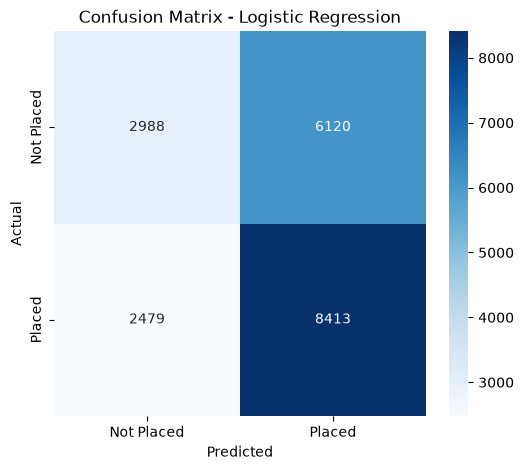

In [36]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Placed", "Placed"],
    yticklabels=["Not Placed", "Placed"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [37]:
y_prob = logistic_pipeline.predict_proba(X_test)[:, 1]

In [38]:
roc_auc = roc_auc_score(
    (y_test == "Placed").astype(int),
    y_prob
)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.5849


## 6. Random Forest

In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [41]:
rf_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Not Placed','Placed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['age','gender','cgpa',...,'volunteer_experience','sleep_hours', 'study_hours_per_day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [44]:
rf_pred = rf_pipeline.predict(X_test)

In [45]:
print(rf_pred[:10])

['Not Placed' 'Not Placed' 'Placed' 'Not Placed' 'Placed' 'Placed'
 'Placed' 'Placed' 'Not Placed' 'Placed']


In [46]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    pos_label="Placed"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    pos_label="Placed"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    pos_label="Placed"
)

print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Accuracy : 0.5582
Precision: 0.5717
Recall   : 0.7527
F1 Score : 0.6498


In [47]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

  Not Placed       0.52      0.33      0.40      9108
      Placed       0.57      0.75      0.65     10892

    accuracy                           0.56     20000
   macro avg       0.55      0.54      0.53     20000
weighted avg       0.55      0.56      0.54     20000



In [48]:
rf_prob = rf_pipeline.predict_proba(X_test)[:, 1]

rf_roc_auc = roc_auc_score(
    (y_test == "Placed").astype(int),
    rf_prob
)

print(f"ROC-AUC: {rf_roc_auc:.4f}")

ROC-AUC: 0.5630


In [49]:
baseline_accuracy = (y_test == "Placed").mean()

print(f"Majority Class Baseline Accuracy: {baseline_accuracy:.4f}")

Majority Class Baseline Accuracy: 0.5446


In [50]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [51]:
X_train_encoded = preprocessor.fit_transform(X_train)

print("Original features:", X_train.shape[1])
print("Encoded features:", X_train_encoded.shape[1])

Original features: 23
Encoded features: 32


In [52]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

gb_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

In [53]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [54]:
gb_pipeline = Pipeline(
    steps=[
        ("preprocessor", gb_preprocessor),
        (
            "model",
            HistGradientBoostingClassifier(
                max_iter=200,
                learning_rate=0.1,
                random_state=42
            )
        )
    ]
)

In [55]:
gb_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Not Placed','Placed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['age','gender','cgpa',...,'volunteer_experience','sleep_hours', 'study_hours_per_day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyin

In [56]:
gb_pred = gb_pipeline.predict(X_test)

In [57]:
print(gb_pred[:10])

['Not Placed' 'Not Placed' 'Placed' 'Not Placed' 'Placed' 'Placed'
 'Placed' 'Placed' 'Placed' 'Placed']


In [58]:
gb_accuracy = accuracy_score(y_test, gb_pred)

gb_precision = precision_score(
    y_test,
    gb_pred,
    pos_label="Placed"
)

gb_recall = recall_score(
    y_test,
    gb_pred,
    pos_label="Placed"
)

gb_f1 = f1_score(
    y_test,
    gb_pred,
    pos_label="Placed"
)

print(f"Accuracy : {gb_accuracy:.4f}")
print(f"Precision: {gb_precision:.4f}")
print(f"Recall   : {gb_recall:.4f}")
print(f"F1 Score : {gb_f1:.4f}")

Accuracy : 0.5658
Precision: 0.5727
Recall   : 0.7981
F1 Score : 0.6669


In [59]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

  Not Placed       0.54      0.29      0.38      9108
      Placed       0.57      0.80      0.67     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.54      0.52     20000
weighted avg       0.56      0.57      0.53     20000



In [60]:
gb_prob = gb_pipeline.predict_proba(X_test)[:, 1]

gb_roc_auc = roc_auc_score(
    (y_test == "Placed").astype(int),
    gb_prob
)

print(f"ROC-AUC: {gb_roc_auc:.4f}")

ROC-AUC: 0.5767


In [61]:
fitted_preprocessor = logistic_pipeline.named_steps["preprocessor"]

In [62]:
model = logistic_pipeline.named_steps["model"]

In [63]:
feature_names = fitted_preprocessor.get_feature_names_out()

print("Number of features:", len(feature_names))

Number of features: 32


In [64]:
coefficients = model.coef_[0]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})

feature_importance["Absolute_Coefficient"] = (
    feature_importance["Coefficient"].abs()
)

feature_importance = feature_importance.sort_values(
    "Absolute_Coefficient",
    ascending=False
)

feature_importance.head(15)

,Feature,Coefficient,Absolute_Coefficient
14,num__backlogs,-0.172704,0.172704
2,num__internships_count,0.128343,0.128343
3,num__projects_count,0.126298,0.126298
5,num__coding_skill_score,0.106354,0.106354
12,num__mock_interview_score,0.094282,0.094282
8,num__logical_reasoning_score,0.073885,0.073885
6,num__aptitude_score,0.066454,0.066454
7,num__communication_skill_score,0.062122,0.062122
16,num__leadership_score,0.046627,0.046627
15,num__extracurricular_score,0.040599,0.040599


## Model Results — Initial Comparison

Initial models were evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

Logistic Regression achieved the best overall ROC-AUC and accuracy among the initial models, while Gradient Boosting achieved the highest recall and F1-score.

In [66]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        gb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        gb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        gb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        gb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        gb_roc_auc
    ]
})

results.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.5700,0.5789,0.7724,0.6618,0.5849
1,Random Forest,0.5582,0.5717,0.7527,0.6498,0.5630
2,Gradient Boosting,0.5658,0.5727,0.7981,0.6669,0.5767


## Feature Engineering
## 7. Feature Engineering

New features are created by combining related student attributes into meaningful
readiness scores. These features aim to capture broader patterns that individual
variables may not represent on their own.

In [75]:
def create_engineered_features(data):
    data = data.copy()

    data["technical_readiness"] = (
        data["coding_skill_score"] +
        data["projects_count"] * 5 +
        data["internships_count"] * 5 +
        data["github_repos"] * 2 +
        data["hackathons_participated"] * 2
    )

    data["interview_readiness"] = (
        data["aptitude_score"] +
        data["communication_skill_score"] + 
        data["logical_reasoning_score"] + 
        data["mock_interview_score"]
    ) / 4

    data["academic_strength"] = (
        data["cgpa"] * 10 +
        data["attendance_percentage"] -
        data["backlogs"] * 10
    )

    return data

In [76]:
X_train_eng = create_engineered_features(X_train)
X_test_eng = create_engineered_features(X_test)

In [77]:
print("Original features:", X_train.shape[1])
print("Engineered features:", X_train_eng.shape[1])

Original features: 23
Engineered features: 26


In [78]:
print("X_train shape:", X_train.shape)
print("X_train_eng shape:", X_train_eng.shape)

print("\nNew columns:")
print(X_train_eng.columns.difference(X_train.columns).tolist())

X_train shape: (80000, 23)
X_train_eng shape: (80000, 26)

New columns:
['academic_strength', 'interview_readiness', 'technical_readiness']


In [79]:
X_train_eng[
    [
        "technical_readiness",
        "interview_readiness",
        "academic_strength"
    ]
].describe()

,technical_readiness,interview_readiness,academic_strength
count,80000.000000,80000.000000,80000.000000
mean,102.356773,67.221549,154.713966
std,18.567347,6.963243,15.396718
min,32.585682,38.152482,82.700927
25%,89.683977,62.500504,144.584853
50%,102.212968,67.235451,155.239462
75%,114.959434,71.946225,165.442307
max,179.585326,95.430972,200.000000


In [80]:
X_train_eng[
    [
        "technical_readiness",
        "interview_readiness",
        "academic_strength"
    ]
].head()

,technical_readiness,interview_readiness,academic_strength
12685,111.843235,71.383779,184.600000
72956,107.622987,70.899083,157.502634
75845,91.626704,61.910314,144.700000
83333,98.343441,57.781367,159.383848
76658,96.464530,65.584831,143.460617


In [81]:
engineered_numerical_features = numerical_features + [
    "technical_readiness",
    "interview_readiness",
    "academic_strength"
]

print("Numerical features:", len(engineered_numerical_features))
print(engineered_numerical_features)

Numerical features: 22
['age', 'cgpa', 'internships_count', 'projects_count', 'certifications_count', 'coding_skill_score', 'aptitude_score', 'communication_skill_score', 'logical_reasoning_score', 'hackathons_participated', 'github_repos', 'linkedin_connections', 'mock_interview_score', 'attendance_percentage', 'backlogs', 'extracurricular_score', 'leadership_score', 'sleep_hours', 'study_hours_per_day', 'technical_readiness', 'interview_readiness', 'academic_strength']


In [82]:
print("Categorical features:", len(categorical_features))
print(categorical_features)

Categorical features: 4
['gender', 'branch', 'college_tier', 'volunteer_experience']


In [83]:
engineered_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            engineered_numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [84]:
engineered_preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

In [85]:
engineered_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", engineered_preprocessor),
        (
            "model",
            LogisticRegression(max_iter=1000)
        )
    ]
)

In [86]:
engineered_logistic_pipeline.fit(
    X_train_eng,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Not Placed','Placed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['age','gender','cgpa',...,'technical_readiness','interview_readiness', 'academic_strength']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By spec

In [87]:
engineered_logistic_pred = (
    engineered_logistic_pipeline.predict(X_test_eng)
)

In [88]:
eng_accuracy = accuracy_score(
    y_test,
    engineered_logistic_pred
)

eng_precision = precision_score(
    y_test,
    engineered_logistic_pred,
    pos_label="Placed"
)

eng_recall = recall_score(
    y_test,
    engineered_logistic_pred,
    pos_label="Placed"
)

eng_f1 = f1_score(
    y_test,
    engineered_logistic_pred,
    pos_label="Placed"
)

eng_prob = engineered_logistic_pipeline.predict_proba(
    X_test_eng
)[:, 1]

eng_roc_auc = roc_auc_score(
    (y_test == "Placed").astype(int),
    eng_prob
)

print(f"Accuracy : {eng_accuracy:.4f}")
print(f"Precision: {eng_precision:.4f}")
print(f"Recall   : {eng_recall:.4f}")
print(f"F1 Score : {eng_f1:.4f}")
print(f"ROC-AUC  : {eng_roc_auc:.4f}")

Accuracy : 0.5700
Precision: 0.5789
Recall   : 0.7727
F1 Score : 0.6619
ROC-AUC  : 0.5850


In [89]:
feature_engineering_comparison = pd.DataFrame({
    "Version": [
        "Original Features",
        "Engineered Features"
    ],
    "Accuracy": [
        accuracy,
        eng_accuracy
    ],
    "Precision": [
        precision,
        eng_precision
    ],
    "Recall": [
        recall,
        eng_recall
    ],
    "F1 Score": [
        f1,
        eng_f1
    ],
    "ROC-AUC": [
        roc_auc,
        eng_roc_auc
    ]
})

feature_engineering_comparison.round(4)

,Version,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Original Features,0.57,0.5789,0.7724,0.6618,0.5849
1,Engineered Features,0.57,0.5789,0.7727,0.6619,0.5850


In [90]:
prediction_changes = (
    logistic_pipeline.predict(X_test) !=
    engineered_logistic_pred
).sum()

print("Changed predictions:", prediction_changes)

Changed predictions: 22


## 8. Hyperparameter Tuning — Logistic Regression

In [91]:
from sklearn.model_selection import GridSearchCV

In [92]:
logistic_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            LogisticRegression(max_iter=1000)
        )
    ]
)

In [93]:
param_grid = {
    "model__C": [0.01, 0.1, 1, 10, 100]
}

In [94]:
grid_search = GridSearchCV(
    estimator=logistic_tuning_pipeline,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

In [95]:
grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, w

In [96]:
print("Best C:", grid_search.best_params_)
print("Best CV ROC-AUC:", grid_search.best_score_)

Best C: {'model__C': 0.01}
Best CV ROC-AUC: 0.5854068884541067


In [97]:
tuned_logistic = grid_search.best_estimator_

tuned_pred = tuned_logistic.predict(X_test)

tuned_prob = tuned_logistic.predict_proba(X_test)[:, 1]

tuned_accuracy = accuracy_score(y_test, tuned_pred)
tuned_precision = precision_score(
    y_test,
    tuned_pred,
    pos_label="Placed"
)
tuned_recall = recall_score(
    y_test,
    tuned_pred,
    pos_label="Placed"
)
tuned_f1 = f1_score(
    y_test,
    tuned_pred,
    pos_label="Placed"
)
tuned_roc_auc = roc_auc_score(
    (y_test == "Placed").astype(int),
    tuned_prob
)

print(f"Accuracy : {tuned_accuracy:.4f}")
print(f"Precision: {tuned_precision:.4f}")
print(f"Recall   : {tuned_recall:.4f}")
print(f"F1 Score : {tuned_f1:.4f}")
print(f"ROC-AUC  : {tuned_roc_auc:.4f}")

Accuracy : 0.5701
Precision: 0.5789
Recall   : 0.7730
F1 Score : 0.6620
ROC-AUC  : 0.5849


## 9. Hyperparameter Tuning — Random Forest

In [99]:
rf_tuning_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [98]:
rf_param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

In [100]:
rf_grid_search = GridSearchCV(
    estimator=rf_tuning_pipeline,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

In [101]:
rf_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__max_depth': [None, 10, ...], 'model__min_samples_split': [2, 5], 'model__n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose:

In [102]:
print("Best parameters:")
print(rf_grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(rf_grid_search.best_score_)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best CV ROC-AUC:
0.5805181649922326


In [103]:
tuned_rf = rf_grid_search.best_estimator_

tuned_rf_pred = tuned_rf.predict(X_test)
tuned_rf_prob = tuned_rf.predict_proba(X_test)[:, 1]

tuned_rf_accuracy = accuracy_score(y_test, tuned_rf_pred)

tuned_rf_precision = precision_score(
    y_test,
    tuned_rf_pred,
    pos_label="Placed"
)

tuned_rf_recall = recall_score(
    y_test,
    tuned_rf_pred,
    pos_label="Placed"
)

tuned_rf_f1 = f1_score(
    y_test,
    tuned_rf_pred,
    pos_label="Placed"
)

tuned_rf_roc_auc = roc_auc_score(
    (y_test == "Placed").astype(int),
    tuned_rf_prob
)

print(f"Accuracy : {tuned_rf_accuracy:.4f}")
print(f"Precision: {tuned_rf_precision:.4f}")
print(f"Recall   : {tuned_rf_recall:.4f}")
print(f"F1 Score : {tuned_rf_f1:.4f}")
print(f"ROC-AUC  : {tuned_rf_roc_auc:.4f}")

Accuracy : 0.5623
Precision: 0.5639
Recall   : 0.8664
F1 Score : 0.6831
ROC-AUC  : 0.5789


## 10. Hyperparameter Tuning — Gradient Boosting

In [104]:
gb_param_grid = {
    "model__max_iter": [100, 200],
    "model__learning_rate": [0.05, 0.1],
    "model__max_leaf_nodes": [15, 31]
}

In [105]:
gb_grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

In [106]:
gb_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__learning_rate': [0.05, 0.1], 'model__max_iter': [100, 200], 'model__max_leaf_nodes': [15, 31]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int,

In [107]:
print("Best parameters:")
print(gb_grid_search.best_params_)

print("\nBest CV ROC-AUC:")
print(gb_grid_search.best_score_)

Best parameters:
{'model__learning_rate': 0.05, 'model__max_iter': 100, 'model__max_leaf_nodes': 15}

Best CV ROC-AUC:
0.5791762192880744


In [108]:
feature_engineering_comparison = pd.DataFrame({
    "Version": [
        "Original Features",
        "Engineered Features"
    ],
    "Accuracy": [
        accuracy,
        eng_accuracy
    ],
    "Precision": [
        precision,
        eng_precision
    ],
    "Recall": [
        recall,
        eng_recall
    ],
    "F1 Score": [
        f1,
        eng_f1
    ],
    "ROC-AUC": [
        roc_auc,
        eng_roc_auc
    ]
})

feature_engineering_comparison.round(4)

,Version,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Original Features,0.57,0.5789,0.7724,0.6618,0.5849
1,Engineered Features,0.57,0.5789,0.7727,0.6619,0.5850


In [109]:
tuned_gb = gb_grid_search.best_estimator_

tuned_gb_pred = tuned_gb.predict(X_test)
tuned_gb_prob = tuned_gb.predict_proba(X_test)[:, 1]

tuned_gb_accuracy = accuracy_score(y_test, tuned_gb_pred)

tuned_gb_precision = precision_score(
    y_test,
    tuned_gb_pred,
    pos_label="Placed"
)

tuned_gb_recall = recall_score(
    y_test,
    tuned_gb_pred,
    pos_label="Placed"
)

tuned_gb_f1 = f1_score(
    y_test,
    tuned_gb_pred,
    pos_label="Placed"
)

tuned_gb_roc_auc = roc_auc_score(
    (y_test == "Placed").astype(int),
    tuned_gb_prob
)

print(f"Accuracy : {tuned_gb_accuracy:.4f}")
print(f"Precision: {tuned_gb_precision:.4f}")
print(f"Recall   : {tuned_gb_recall:.4f}")
print(f"F1 Score : {tuned_gb_f1:.4f}")
print(f"ROC-AUC  : {tuned_gb_roc_auc:.4f}")

Accuracy : 0.5658
Precision: 0.5720
Recall   : 0.8051
F1 Score : 0.6688
ROC-AUC  : 0.5788


In [110]:
threshold_results = []

for threshold in np.arange(0.30, 0.71, 0.05):

    threshold_pred = np.where(
        y_prob >= threshold,
        "Placed",
        "Not Placed"
    )

    threshold_accuracy = accuracy_score(
        y_test,
        threshold_pred
    )

    threshold_precision = precision_score(
        y_test,
        threshold_pred,
        pos_label="Placed",
        zero_division=0
    )

    threshold_recall = recall_score(
        y_test,
        threshold_pred,
        pos_label="Placed",
        zero_division=0
    )

    threshold_f1 = f1_score(
        y_test,
        threshold_pred,
        pos_label="Placed",
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": threshold_accuracy,
        "Precision": threshold_precision,
        "Recall": threshold_recall,
        "F1": threshold_f1
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.round(4)

,Threshold,Accuracy,Precision,Recall,F1
0,0.30,0.5451,0.5449,0.9986,0.7051
1,0.35,0.5474,0.5464,0.9943,0.7052
2,0.40,0.5552,0.5519,0.9737,0.7045
3,0.45,0.5648,0.5618,0.9124,0.6954
4,0.50,0.5700,0.5789,0.7724,0.6618
5,0.55,0.5562,0.6031,0.5413,0.5705
6,0.60,0.5242,0.6432,0.2840,0.3940
7,0.65,0.4853,0.6883,0.1003,0.1752
8,0.70,0.4631,0.7421,0.0217,0.0421


In [111]:
threshold_results.sort_values(
    "Accuracy",
    ascending=False
).round(4)

,Threshold,Accuracy,Precision,Recall,F1
4,0.50,0.5700,0.5789,0.7724,0.6618
3,0.45,0.5648,0.5618,0.9124,0.6954
5,0.55,0.5562,0.6031,0.5413,0.5705
2,0.40,0.5552,0.5519,0.9737,0.7045
1,0.35,0.5474,0.5464,0.9943,0.7052
0,0.30,0.5451,0.5449,0.9986,0.7051
6,0.60,0.5242,0.6432,0.2840,0.3940
7,0.65,0.4853,0.6883,0.1003,0.1752
8,0.70,0.4631,0.7421,0.0217,0.0421


In [112]:
placement_by_internship_backlog = (
    df.groupby(["internships_count", "backlogs"])["placement_status"]
    .apply(lambda x: (x == "Placed").mean() * 100)
    .reset_index(name="placement_rate")
)

placement_by_internship_backlog.head(20)

,internships_count,backlogs,placement_rate
0,0,0,53.390767
1,0,1,47.568298
2,0,2,38.814181
3,0,3,38.596491
4,0,4,21.212121
5,0,5,0.000000
6,0,6,0.000000
7,1,0,56.341822
8,1,1,51.947797
9,1,2,42.545305


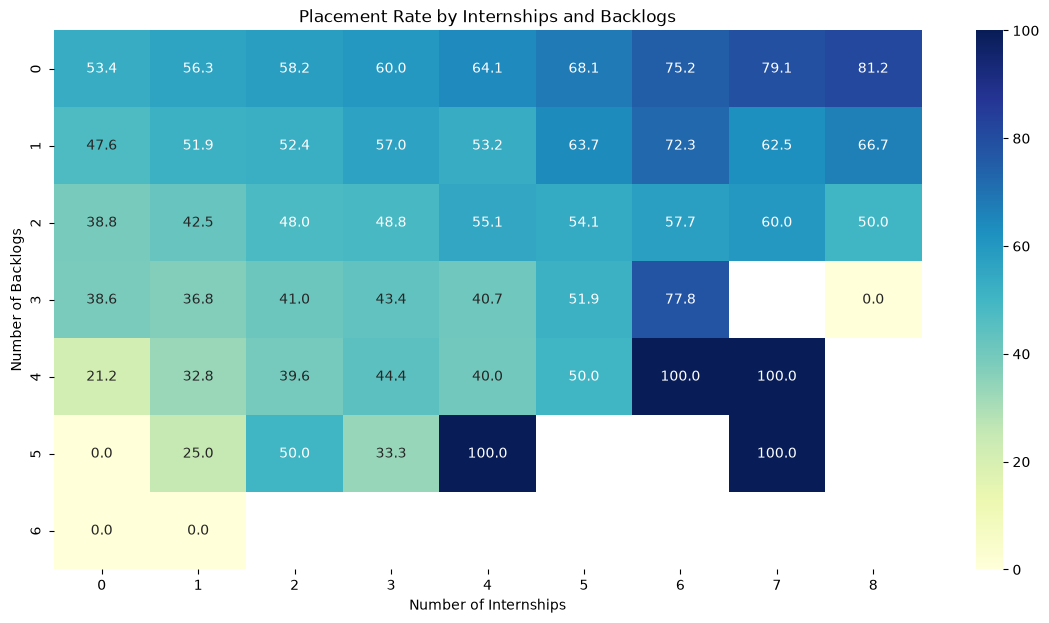

In [113]:
pivot_table = placement_by_internship_backlog.pivot(
    index="backlogs",
    columns="internships_count",
    values="placement_rate"
)

plt.figure(figsize=(14, 7))

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu"
)

plt.title("Placement Rate by Internships and Backlogs")
plt.xlabel("Number of Internships")
plt.ylabel("Number of Backlogs")

plt.show()

## Feature Interaction Analysis

The EDA suggests that the effect of internships on placement may depend on
the number of backlogs. Interaction features are therefore introduced to
allow the model to capture combined effects between important variables.

In [114]:
def create_interaction_features(data):
    data = data.copy()

    # Internship and backlog interaction
    data["internship_backlog_interaction"] = (
        data["internships_count"] * data["backlogs"]
    )

    # Projects and internships interaction
    data["internship_project_interaction"] = (
        data["internships_count"] * data["projects_count"]
    )

    # Coding skill and projects interaction
    data["coding_project_interaction"] = (
        data["coding_skill_score"] * data["projects_count"]
    )

    return data

In [115]:
X_train_interaction = create_interaction_features(X_train)
X_test_interaction = create_interaction_features(X_test)

In [116]:
print("Original features:", X_train.shape[1])
print("Interaction features:", X_train_interaction.shape[1])

Original features: 23
Interaction features: 26


In [117]:
print(
    X_train_interaction.columns.difference(
        X_train.columns
    ).tolist()
)

['coding_project_interaction', 'internship_backlog_interaction', 'internship_project_interaction']


In [118]:
interaction_numerical_features = numerical_features + [
    "internship_backlog_interaction",
    "internship_project_interaction",
    "coding_project_interaction"
]

print(len(interaction_numerical_features))

22


In [119]:
interaction_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            interaction_numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

In [120]:
interaction_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", interaction_preprocessor),
        (
            "model",
            LogisticRegression(
                C=0.01,
                max_iter=1000
            )
        )
    ]
)

In [121]:
interaction_logistic_pipeline.fit(
    X_train_interaction,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Not Placed','Placed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['age','gender','cgpa',...,'internship_backlog_interaction', 'internship_project_interaction','coding_project_interaction']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. 

In [122]:
interaction_pred = (
    interaction_logistic_pipeline.predict(
        X_test_interaction
    )
)

interaction_prob = (
    interaction_logistic_pipeline.predict_proba(
        X_test_interaction
    )[:, 1]
)

In [123]:
interaction_accuracy = accuracy_score(
    y_test,
    interaction_pred
)

interaction_precision = precision_score(
    y_test,
    interaction_pred,
    pos_label="Placed"
)

interaction_recall = recall_score(
    y_test,
    interaction_pred,
    pos_label="Placed"
)

interaction_f1 = f1_score(
    y_test,
    interaction_pred,
    pos_label="Placed"
)

interaction_roc_auc = roc_auc_score(
    (y_test == "Placed").astype(int),
    interaction_prob
)

print(f"Accuracy : {interaction_accuracy:.4f}")
print(f"Precision: {interaction_precision:.4f}")
print(f"Recall   : {interaction_recall:.4f}")
print(f"F1 Score : {interaction_f1:.4f}")
print(f"ROC-AUC  : {interaction_roc_auc:.4f}")

Accuracy : 0.5695
Precision: 0.5781
Recall   : 0.7752
F1 Score : 0.6623
ROC-AUC  : 0.5849


In [125]:
import xgboost

print(xgboost.__version__)

3.2.0


## 11. XGBoost Model

In [126]:
from xgboost import XGBClassifier

In [129]:
xgb_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

In [131]:
y_train_xgb = y_train.map({
    "Not Placed": 0,
    "Placed": 1
})

y_test_xgb = y_test.map({
    "Not Placed": 0,
    "Placed": 1
})

In [135]:
print(y_train_xgb.value_counts())
print(y_test_xgb.value_counts())

placement_status
1    43567
0    36433
Name: count, dtype: int64
placement_status
1    10892
0     9108
Name: count, dtype: int64


In [136]:
print("Original y_train:")
print(y_train.unique())

print("\nXGBoost y_train:")
print(y_train_xgb.unique())

Original y_train:
<StringArray>
['Placed', 'Not Placed']
Length: 2, dtype: str

XGBoost y_train:
[1 0]


In [137]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                subsample=0.8,
                colsample_bytree=0.8,
                random_state=42,
                eval_metric="logloss",
                n_jobs=-1
            )
        )
    ]
)

In [139]:
xgb_pipeline.fit(
    X_train,
    y_train_xgb
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](23,)","['age','gender','cgpa',...,'volunteer_experience','sleep_hours', 'study_hours_per_day']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,23
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='pass

In [140]:
xgb_pred = xgb_pipeline.predict(X_test)
xgb_prob = xgb_pipeline.predict_proba(X_test)[:, 1]

In [141]:
xgb_accuracy = accuracy_score(y_test_xgb, xgb_pred)

xgb_precision = precision_score(
    y_test_xgb,
    xgb_pred
)

xgb_recall = recall_score(
    y_test_xgb,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test_xgb,
    xgb_pred
)

xgb_roc_auc = roc_auc_score(
    y_test_xgb,
    xgb_prob
)

print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

Accuracy : 0.5654
Precision: 0.5738
Recall   : 0.7846
F1 Score : 0.6629
ROC-AUC  : 0.5792


In [142]:
print(
    classification_report(
        y_test_xgb,
        xgb_pred,
        target_names=["Not Placed", "Placed"]
    )
)

              precision    recall  f1-score   support

  Not Placed       0.54      0.30      0.39      9108
      Placed       0.57      0.78      0.66     10892

    accuracy                           0.57     20000
   macro avg       0.56      0.54      0.53     20000
weighted avg       0.56      0.57      0.54     20000



In [143]:
categorical_placement_rates = {}

for col in categorical_features:
    categorical_placement_rates[col] = (
        df.groupby(col)["placement_status"]
        .apply(lambda x: (x == "Placed").mean() * 100)
        .round(2)
    )

categorical_placement_rates

{'gender': gender
 Female    54.38
 Male      54.51
 Name: placement_status, dtype: float64,
 'branch': branch
 CSE           54.64
 Civil         55.17
 ECE           54.11
 EEE           54.32
 IT            54.30
 Mechanical    54.08
 Name: placement_status, dtype: float64,
 'college_tier': college_tier
 Tier 1    54.50
 Tier 2    54.28
 Tier 3    54.72
 Name: placement_status, dtype: float64,
 'volunteer_experience': volunteer_experience
 No     54.41
 Yes    54.53
 Name: placement_status, dtype: float64}

In [144]:
for col in categorical_features:
    print(f"\n--- {col} ---")
    print(
        df.groupby(col)["placement_status"]
        .apply(lambda x: (x == "Placed").mean() * 100)
        .round(2)
    )


--- gender ---
gender
Female    54.38
Male      54.51
Name: placement_status, dtype: float64

--- branch ---
branch
CSE           54.64
Civil         55.17
ECE           54.11
EEE           54.32
IT            54.30
Mechanical    54.08
Name: placement_status, dtype: float64

--- college_tier ---
college_tier
Tier 1    54.50
Tier 2    54.28
Tier 3    54.72
Name: placement_status, dtype: float64

--- volunteer_experience ---
volunteer_experience
No     54.41
Yes    54.53
Name: placement_status, dtype: float64


In [145]:
internship_analysis = (
    df.groupby("internships_count")["placement_status"]
    .agg(
        total_students="count",
        placed=lambda x: (x == "Placed").sum()
    )
)

internship_analysis["placement_rate"] = (
    internship_analysis["placed"] /
    internship_analysis["total_students"] * 100
)

internship_analysis.round(2)

,total_students,placed,placement_rate
internships_count,,,
0,22203,11172,50.32
1,33546,18015,53.70
2,25103,13907,55.40
3,12583,7292,57.95
4,4661,2794,59.94
5,1464,957,65.37
6,344,252,73.26
7,74,54,72.97
8,22,16,72.73


In [146]:
project_analysis = (
    df.groupby("projects_count")["placement_status"]
    .agg(
        total_students="count",
        placed=lambda x: (x == "Placed").sum()
    )
)

project_analysis["placement_rate"] = (
    project_analysis["placed"] /
    project_analysis["total_students"] * 100
)

project_analysis.round(2)

,total_students,placed,placement_rate
projects_count,,,
0,4948,2429,49.09
1,14920,7645,51.24
2,22333,11789,52.79
3,22485,12210,54.30
4,16892,9427,55.81
5,10133,5936,58.58
6,4856,2875,59.21
7,2257,1352,59.90
8,775,508,65.55


In [147]:
three_feature_analysis = (
    df.groupby(
        ["internships_count", "projects_count", "backlogs"]
    )["placement_status"]
    .agg(
        total_students="count",
        placed=lambda x: (x == "Placed").sum()
    )
)

three_feature_analysis["placement_rate"] = (
    three_feature_analysis["placed"] /
    three_feature_analysis["total_students"] * 100
)

three_feature_analysis = three_feature_analysis.reset_index()

three_feature_analysis.sort_values(
    "total_students",
    ascending=False
).head(20)

,internships_count,projects_count,backlogs,total_students,placed,placement_rate
74,1,3,0,4655,2648,56.885070
68,1,2,0,4555,2492,54.709111
80,1,4,0,3439,1960,56.993312
132,2,3,0,3383,1946,57.522909
126,2,2,0,3347,1890,56.468479
17,0,3,0,3087,1649,53.417557
10,0,2,0,3073,1612,52.456883
63,1,1,0,2996,1603,53.504673
138,2,4,0,2599,1546,59.484417
121,2,1,0,2334,1272,54.498715


## Numerical Feature Placement Analysis

In [148]:
numerical_placement_analysis = {}

for col in numerical_features:
    try:
        bins = pd.qcut(
            df[col],
            q=5,
            duplicates="drop"
        )

        rates = (
            df.groupby(
                bins,
                observed=True
            )["placement_status"]
            .apply(lambda x: (x == "Placed").mean() * 100)
        )

        numerical_placement_analysis[col] = rates.round(2)

    except Exception as e:
        print(f"Could not analyze {col}: {e}")

In [149]:
for feature, rates in numerical_placement_analysis.items():
    print(f"\n--- {feature} ---")
    print(rates)


--- age ---
age
(17.999, 19.0]    54.16
(19.0, 20.0]      54.60
(20.0, 22.0]      54.79
(22.0, 23.0]      54.68
(23.0, 24.0]      54.03
Name: placement_status, dtype: float64

--- cgpa ---
cgpa
(4.499, 6.66]    53.42
(6.66, 7.24]     54.41
(7.24, 7.76]     54.45
(7.76, 8.34]     54.75
(8.34, 10.0]     55.29
Name: placement_status, dtype: float64

--- internships_count ---
internships_count
(-0.001, 1.0]    52.35
(1.0, 2.0]       55.40
(2.0, 8.0]       59.35
Name: placement_status, dtype: float64

--- projects_count ---
projects_count
(-0.001, 2.0]    51.81
(2.0, 3.0]       54.30
(3.0, 4.0]       55.81
(4.0, 13.0]      59.49
Name: placement_status, dtype: float64

--- certifications_count ---
certifications_count
(-0.001, 1.0]    54.72
(1.0, 2.0]       54.17
(2.0, 3.0]       54.46
(3.0, 11.0]      54.25
Name: placement_status, dtype: float64

--- coding_skill_score ---
coding_skill_score
(19.999, 57.307]    50.86
(57.307, 66.219]    53.09
(66.219, 73.736]    54.44
(73.736, 82.534]    5

In [150]:
feature_signal = []

for feature, rates in numerical_placement_analysis.items():
    feature_signal.append({
        "Feature": feature,
        "Minimum Placement Rate": rates.min(),
        "Maximum Placement Rate": rates.max(),
        "Difference": rates.max() - rates.min()
    })

feature_signal = pd.DataFrame(feature_signal)

feature_signal.sort_values(
    "Difference",
    ascending=False
).round(2)

,Feature,Minimum Placement Rate,Maximum Placement Rate,Difference
14,backlogs,43.85,55.50,11.65
3,projects_count,51.81,59.49,7.68
5,coding_skill_score,50.86,58.27,7.41
2,internships_count,52.35,59.35,7.00
12,mock_interview_score,51.18,57.72,6.54
8,logical_reasoning_score,52.04,57.03,4.99
7,communication_skill_score,52.34,57.16,4.82
6,aptitude_score,52.24,56.38,4.14
15,extracurricular_score,53.13,55.98,2.85
16,leadership_score,52.99,55.76,2.77


## Feature Selection

In [151]:
strong_features = [
    "backlogs",
    "projects_count",
    "coding_skill_score",
    "internships_count",
    "mock_interview_score",
    "logical_reasoning_score",
    "communication_skill_score",
    "aptitude_score"
]

print("Number of selected features:", len(strong_features))

Number of selected features: 8


In [152]:
X_train_strong = X_train[strong_features]
X_test_strong = X_test[strong_features]

In [153]:
print("Training:", X_train_strong.shape)
print("Testing:", X_test_strong.shape)

Training: (80000, 8)
Testing: (20000, 8)


In [154]:
strong_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            strong_features
        )
    ]
)

In [155]:
strong_logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", strong_preprocessor),
        (
            "model",
            LogisticRegression(
                C=0.01,
                max_iter=1000
            )
        )
    ]
)

In [156]:
strong_logistic_pipeline.fit(
    X_train_strong,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](2,)","['Not Placed','Placed']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](8,)","['backlogs','projects_count','coding_skill_score',..., 'logical_reasoning_score','communication_skill_score','aptitude_score']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,8
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of `

In [157]:
strong_pred = strong_logistic_pipeline.predict(
    X_test_strong
)

strong_prob = strong_logistic_pipeline.predict_proba(
    X_test_strong
)[:, 1]

In [158]:
strong_accuracy = accuracy_score(
    y_test,
    strong_pred
)

strong_precision = precision_score(
    y_test,
    strong_pred,
    pos_label="Placed"
)

strong_recall = recall_score(
    y_test,
    strong_pred,
    pos_label="Placed"
)

strong_f1 = f1_score(
    y_test,
    strong_pred,
    pos_label="Placed"
)

strong_roc_auc = roc_auc_score(
    (y_test == "Placed").astype(int),
    strong_prob
)

print(f"Accuracy : {strong_accuracy:.4f}")
print(f"Precision: {strong_precision:.4f}")
print(f"Recall   : {strong_recall:.4f}")
print(f"F1 Score : {strong_f1:.4f}")
print(f"ROC-AUC  : {strong_roc_auc:.4f}")

Accuracy : 0.5700
Precision: 0.5779
Recall   : 0.7805
F1 Score : 0.6641
ROC-AUC  : 0.5844
